In [1]:
import torch
import sys

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("⚠️ No GPU detected. Some cells may run slowly.")
    print("   Go to Runtime → Change runtime type → GPU")

print(f"\n📦 Python {sys.version.split()[0]}")
print(f"🔥 PyTorch {torch.__version__}")

# Set random seed for reproducibility
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🎲 Random seed set to {SEED}")

%matplotlib inline

✅ GPU available: NVIDIA GB10
   Memory: 130.7 GB

📦 Python 3.11.15
🔥 PyTorch 2.13.0+cu130
🎲 Random seed set to 42


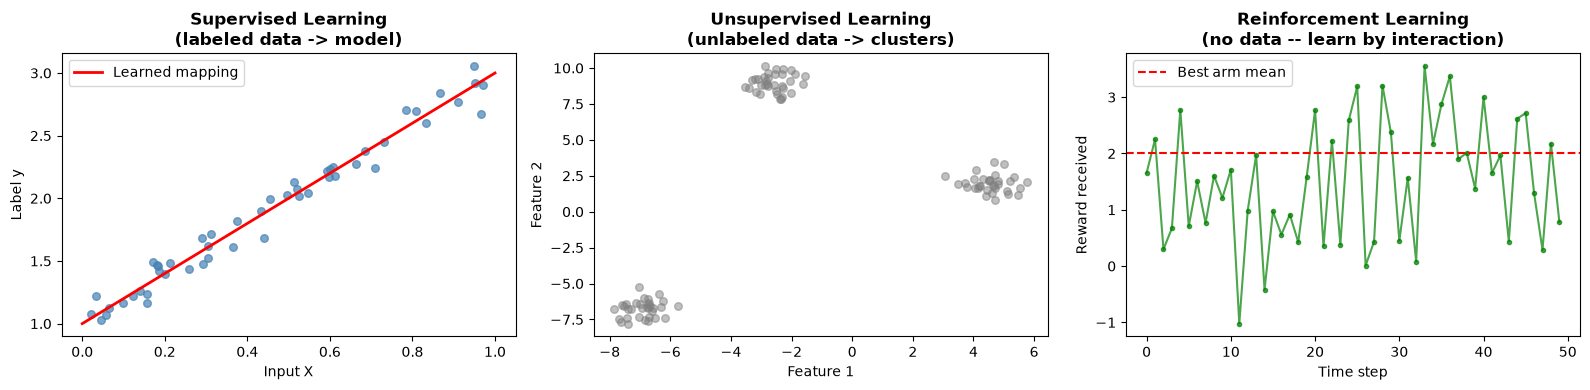

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Supervised Learning: learn from labeled examples
# -------------------------------------------------------
# Simple linear regression: y = 2x + 1
np.random.seed(42)
X_supervised = np.random.rand(50)
y_supervised = 2 * X_supervised + 1 + np.random.randn(50) * 0.1

# -------------------------------------------------------
# Unsupervised Learning: find structure without labels
# -------------------------------------------------------
from sklearn.datasets import make_blobs
X_unsupervised, _ = make_blobs(n_samples=100, centers=3, cluster_std=0.6, random_state=42)

# -------------------------------------------------------
# Reinforcement Learning: learn by interaction
# -------------------------------------------------------
# Simple bandit: agent picks arms, receives rewards
n_arms = 3
true_means = [1.0, 2.0, 1.5] # arm 0, 1, 2
rl_rewards = []
rl_choices = []

# Random agent -- no learning yet
for step in range(50):
    arm = np.random.randint(n_arms)
    reward = np.random.randn() + true_means[arm]
    rl_choices.append(arm)
    rl_rewards.append(reward)



# Visualize all three paradigms
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: Supervised
axes[0].scatter(X_supervised, y_supervised, c='steelblue', alpha=0.7, s=30)
axes[0].plot([0, 1], [1, 3], 'r-', linewidth=2, label='Learned mapping')
axes[0].set_title('Supervised Learning\n(labeled data -> model)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Input X')
axes[0].set_ylabel('Label y')
axes[0].legend()

# Panel 2: Unsupervised
axes[1].scatter(X_unsupervised[:, 0], X_unsupervised[:, 1], c='gray', alpha=0.5, s=30)
axes[1].set_title('Unsupervised Learning\n(unlabeled data -> clusters)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

# Panel 3: RL
axes[2].plot(rl_rewards, 'o-', markersize=3, alpha=0.7, color='green')
axes[2].axhline(y=max(true_means), color='red', linestyle='--', label='Best arm mean')
axes[2].set_title('Reinforcement Learning\n(no data -- learn by interaction)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Time step')
axes[2].set_ylabel('Reward received')
axes[2].legend()

plt.tight_layout()
plt.show()

In [3]:
print("Key insight: In RL, there is no dataset. The agent generates its own data through interaction.")

Key insight: In RL, there is no dataset. The agent generates its own data through interaction.


## 3. The Mathematics

The goal of an RL agent is to find a **policy** $\pi$ (a strategy for choosing actions) that maximizes the **expected cumulative reward**:

$$\max_{\pi} \; \mathbb{E}\left[\sum_{t=0}^{T} r_t\right]$$

Here:
- $\pi$ is the policy (maps states to actions)
- $r_t$ is the reward at time step $t$
- $T$ is the final time step of the episode

Let us compute this by hand for a simple example.

In [8]:
rewards = [1, 0, 1, 1, 0]
t = 1
print(rewards[t:])

[0, 1, 1, 0]


In [6]:
# A robot collects cans over 5 time steps
rewards = [1, 0, 1, 1, 0]

# Compute cumulative return from each time step
print("Time step | Reward | Return from here onward")
print("-" * 55)
for t in range(len(rewards)):
    G_t = sum(rewards[t:])
    print(f"    t={t}    |   {rewards[t]}    |   G_{t} = {' + '.join(map(str, rewards[t:]))} = {G_t}")

total = sum(rewards)
print(f"\nTotal return G_0 = {total}")
print(f"The agent wants to find a policy that makes G_0 as large as possible.")

Time step | Reward | Return from here onward
-------------------------------------------------------
    t=0    |   1    |   G_0 = 1 + 0 + 1 + 1 + 0 = 3
    t=1    |   0    |   G_1 = 0 + 1 + 1 + 0 = 2
    t=2    |   1    |   G_2 = 1 + 1 + 0 = 2
    t=3    |   1    |   G_3 = 1 + 0 = 1
    t=4    |   0    |   G_4 = 0 = 0

Total return G_0 = 3
The agent wants to find a policy that makes G_0 as large as possible.


In [9]:
# A simple deterministic policy for a grid world
# States: positions on a 4x4 grid (0-15)
# Actions: 0=up, 1=right, 2=down, 3=left

def simple_policy(state):
    """A hand-coded policy: always go right, then down"""
    row, col = state // 4, state % 4
    if col < 3:
        return 1 # go right
    else:
        return 2 # go down

# Test the policy
print("Policy decisions:")  
for state in range(16):
    action = simple_policy(state)
    action_name = ['up', 'right', 'down', 'left'][action]
    row, col = state // 4, state % 4
    print(f"  State {state:2d} (row={row}, col={col}) -> action: {action_name}")

Policy decisions:
  State  0 (row=0, col=0) -> action: right
  State  1 (row=0, col=1) -> action: right
  State  2 (row=0, col=2) -> action: right
  State  3 (row=0, col=3) -> action: down
  State  4 (row=1, col=0) -> action: right
  State  5 (row=1, col=1) -> action: right
  State  6 (row=1, col=2) -> action: right
  State  7 (row=1, col=3) -> action: down
  State  8 (row=2, col=0) -> action: right
  State  9 (row=2, col=1) -> action: right
  State 10 (row=2, col=2) -> action: right
  State 11 (row=2, col=3) -> action: down
  State 12 (row=3, col=0) -> action: right
  State 13 (row=3, col=1) -> action: right
  State 14 (row=3, col=2) -> action: right
  State 15 (row=3, col=3) -> action: down


In [16]:
# Different reward structures for different problems
print("Example reward structures:\n")

# Chess
print("Chess:")
print("  Win:  +1")
print("  Lose: -1")
print("  Draw:  0")
print()

# Robot in maze
print("Robot in maze:")
maze_rewards = [-1, -1, -1, -1, -1, 0]  # -1 per step, 0 at exit
print(f"  Rewards per step: {maze_rewards}")
print(f"  Total: {sum(maze_rewards)} (faster escape = less negative total)")
print()

# Robot collecting cans
print("Robot collecting cans:")
can_rewards = [1, 0, 0, 1, 1, 0, 1]
print(f"  Rewards per step: {can_rewards}")
print(f"  Total cans collected: {sum(can_rewards)}")

Example reward structures:

Chess:
  Win:  +1
  Lose: -1
  Draw:  0

Robot in maze:
  Rewards per step: [-1, -1, -1, -1, -1, 0]
  Total: -5 (faster escape = less negative total)

Robot collecting cans:
  Rewards per step: [1, 0, 0, 1, 1, 0, 1]
  Total cans collected: 4


In [17]:
# Value function for a simple 5-state chain
# States: [0] -> [1] -> [2] -> [3] -> [4=goal]
# Reward: +1 at goal, 0 elsewhere

# True values (under optimal policy: always move right)
# V(s) = probability of reaching goal * reward
# With deterministic transitions:
# V(4) = 1.0 (at goal)
# V(3) = 1.0 (one step to goal)
# V(2) = 1.0 (two steps to goal)
# V(1) = 1.0 (three steps to goal)
# V(0) = 1.0 (four steps to goal)

# But with stochastic transitions (50% chance of staying):
gamma = 0.9
V_stochastic = [0.0] * 5
V_stochastic[4] = 1.0  # goal

# Work backwards: V(s) = 0.5 * gamma * V(s) + 0.5 * gamma * V(s+1)
# Rearranging: V(s) = (0.5 * gamma * V(s+1)) / (1 - 0.5 * gamma)
for s in range(3, -1, -1):
    V_stochastic[s] = (0.5 * gamma * V_stochastic[s + 1]) / (1 - 0.5 * gamma)

print("State values (stochastic transitions, gamma=0.9):")
for s in range(5):
    bar = "#" * int(V_stochastic[s] * 40)
    print(f"  State {s}: V = {V_stochastic[s]:.4f}  {bar}")

print("\nKey insight: States closer to the goal have higher value.")
print("The value function captures LONG-TERM desirability, not just immediate reward.")

State values (stochastic transitions, gamma=0.9):
  State 0: V = 0.4481  #################
  State 1: V = 0.5477  #####################
  State 2: V = 0.6694  ##########################
  State 3: V = 0.8182  ################################
  State 4: V = 1.0000  ########################################

Key insight: States closer to the goal have higher value.
The value function captures LONG-TERM desirability, not just immediate reward.


In [22]:
# A simple environment model (transition table)
# Two states: High battery, Low battery
# Two actions: Search, Wait

model = {
    ('High', 'Search'): [('High', 0.7, 2), ('Low', 0.3, 2)],
    ('High', 'Wait'):   [('High', 1.0, 1)],
    ('Low', 'Search'):  [('Low', 0.4, 2), ('Dead', 0.6, -3)],
    ('Low', 'Wait'):    [('Low', 1.0, 1)],
    ('Low', 'Recharge'):[('High', 1.0, 0)],
}

print("Environment Model (Recycling Robot):")
print("=" * 60)
for (state, action), transitions in model.items():
    print(f"\n  State: {state}, Action: {action}")
    for next_state, prob, reward in transitions:
        print(f"    -> {next_state} with prob {prob:.1f}, reward = {reward}")

print("\nModel-based: agent can PLAN by simulating the model.")
print("Model-free: agent learns directly from experience.")

Environment Model (Recycling Robot):

  State: High, Action: Search
    -> High with prob 0.7, reward = 2
    -> Low with prob 0.3, reward = 2

  State: High, Action: Wait
    -> High with prob 1.0, reward = 1

  State: Low, Action: Search
    -> Low with prob 0.4, reward = 2
    -> Dead with prob 0.6, reward = -3

  State: Low, Action: Wait
    -> Low with prob 1.0, reward = 1

  State: Low, Action: Recharge
    -> High with prob 1.0, reward = 0

Model-based: agent can PLAN by simulating the model.
Model-free: agent learns directly from experience.


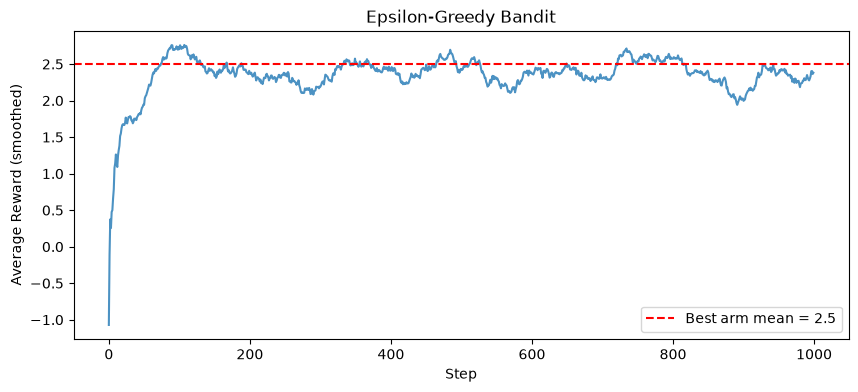

In [24]:
# TODO: Implement epsilon-greedy bandit

n_arms = 4
true_means = [1.0, 2.5, 1.8, 0.5]
n_steps = 1000
epsilon = 0.1

# Track estimates and counts
Q = np.zeros(n_arms)       # estimated value of each arm
N = np.zeros(n_arms)       # number of times each arm was pulled
rewards_history = []

for step in range(n_steps):
    if np.random.random() < epsilon:
        arm = np.random.randint(n_arms)
    else:
        arm = np.argmax(Q)

    # Get reward (noisy version of true mean)
    reward = np.random.randn() + true_means[arm]
    N[arm] += 1
    Q[arm] = Q[arm] + (1 / N[arm]) * (reward - Q[arm])
    # TODO: Update Q[arm] using incremental mean formula:
    # Q[arm] = Q[arm] + (1 / N[arm]) * (reward - Q[arm])
    # Don't forget to increment N[arm] first!
  

    rewards_history.append(reward)

# Plot results
plt.figure(figsize=(10, 4))
window = 50
smoothed = [np.mean(rewards_history[max(0,i-window):i+1]) for i in range(len(rewards_history))]
plt.plot(smoothed, alpha=0.8)
plt.axhline(y=max(true_means), color='red', linestyle='--', label=f'Best arm mean = {max(true_means)}')
plt.xlabel('Step')
plt.ylabel('Average Reward (smoothed)')
plt.title('Epsilon-Greedy Bandit')
plt.legend()
plt.show()


In [25]:
print(f"Estimated values: {Q}")
print(f"True means:       {true_means}")
print(f"Arm pull counts:  {N}")

Estimated values: [1.04242953 2.50124796 1.59060539 0.73727796]
True means:       [1.0, 2.5, 1.8, 0.5]
Arm pull counts:  [ 25. 905.  35.  35.]


In [27]:
# TODO: Compute returns for each reward sequence

# Sequence A: episodic (no discounting)
rewards_a = [0, 0, 0, 1]
print("Sequence A (episodic, no discounting):")
for t in range(len(rewards_a)):
    G_t = sum(rewards_a[t:])

    print(f"  G_{t} = {G_t}")

Sequence A (episodic, no discounting):
  G_0 = 1
  G_1 = 1
  G_2 = 1
  G_3 = 1


In [28]:
print()

# Sequence B: discounted with gamma = 0.9
rewards_b = [1, 2, 3, 4]
gamma = 0.9
print(f"Sequence B (discounted, gamma={gamma}):")
for t in range(len(rewards_b)):
    G_t = 0
    for k, reward in enumerate(rewards_b[t:]):
        G_t += reward * gamma**k
    print(f"  G_{t} = {G_t}")


Sequence B (discounted, gamma=0.9):
  G_0 = 8.146
  G_1 = 7.94
  G_2 = 6.6
  G_3 = 4.0


### Creating environment for the agent

In [7]:
import numpy as np
from collections import defaultdict

class TicTacToeEnv:
    """
    Simple Tic-Tac-Toe environment
    State: Present arrangement of pieces on the board
    Action: choose one of nine board positions
    Reward: 1, -1, 0
    """

    def __init__(self):
        """
        Creating the initial game
        """ 
        self.board = [0] * 9
        self.current_player = 1 # X goes first
        return tuple(self.board)

    def reset(self):
        """
        In reinforcement learning, an episode is one complete interation sequense, here one complete interaction sequense is one complete Tic-Tac-Toe game.
        empty board -> moves -> win or draw
        """
        self.board = [0] * 9
        self.current_player = 1
        return tuple(self.board)

    def get_state(self):
        """
        Reading current state.
        """
        return tuple(self.board)

    def available_actions(self):
        """ 
        This is just checking all the available actions that can be taken
        """
        return [i for i in range(9) if self.board[i] == 0]
    
    def step(self, action):
        """ 
        Take action (place piece), return (state, reward, done)
        """ 
        if action not in self.available_actions():
            raise ValueError(f"Illegal action: {action}")
        self.board[action] = self.current_player
        winner = self._check_winner()

        if winner != 0:
            return tuple(self.board), winner, True 

        elif 0 not in self.board:
            return tuple(self.board), 0, True

        else:
            self.current_player *= -1
            return tuple(self.board), 0, False  
    
    def _checking_winner(self):
        """
        These are the eight possible winning lines:
            Three rows
            Three columns
            Two diagonals
        """
        lines = [
            [0,1,2], [3,4,5], [6,7,8],
            [0,3,6], [1,4,7], [2,5,8],
            [0,4,8], [2,4,6]
        ]
        for line in lines:
            s = sum(self.board[i] for i in line)
            if s == 3:
                return 1 # X wins
            if s == -3:
                return -1 # O wins
        return 0

    def render(self):
        """ 
        This converts internal numerical values as readable symbols
        """ 
        symbols = {0: '.', 1: 'X', -1: 'O'}

        for i in range(0, 9, 3):
            print(' '.join(symbols[self.board[j]] for j in range(i, i+3)))